In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import GWFish.modules as gw
import gc
import torch
from dingo.core.posterior_models.build_model import build_model_from_kwargs
import pandas as pd
from dingo.gw.inference.gw_samplers import GWSampler
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset


os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # use GPU 1
waveform_model = 'IMRPhenomXPHM'
f_ref = 20.
detectors = ['ET']
network = gw.detection.Network(detector_ids = detectors, detection_SNR = (0., 8.))


/home/tpausch/.conda/envs/ET-DINGO/lib/python3.10/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Define functions

In [8]:
def simulate_injections(name, num_injections):

    pm = build_model_from_kwargs(
        filename=f"/scratch/tpausch/models/{name}/model_latest.pt",
        device="cuda",
        load_training_info=False,
    )

    
    out_dir = f"/scratch/tpausch/test_data/{name}/injections"
    os.makedirs(out_dir, exist_ok=True)

    np.random.seed(42)  # optional, for reproducibility

    injection_generator = injection.Injection.from_posterior_model_metadata(
        pm.metadata
    )

    asd_fname = pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)

    injection_generator.asd = {
        k: v[0] for k, v in asd_dataset.asds.items()
    }

    # This is the combined intrinsic + extrinsic bilby PriorDict
    # that the network was trained on
    prior = injection_generator.prior
    print(prior)

    # ============================================================
    # Draw and run injections
    # ============================================================

    for idx in range(num_injections):

        print(f"Running injection {idx}")

        theta = prior.sample()
        theta = {k: float(v) for k, v in theta.items()}  # cast numpy -> float

        strain_data = injection_generator.injection(theta)

        payload = {
            "theta_true": theta,
            "strain_data": strain_data,
        }

        fname = os.path.join(out_dir, f"inj_{idx:04d}.pkl")

        with open(fname, "wb") as f:
            pickle.dump(payload, f)

    print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
    print(torch.cuda.memory_reserved() / 1e9, "GB reserved")
    del pm
    gc.collect()
    torch.cuda.empty_cache()
    return 1 

In [6]:
def infere_parameters(name):


    pm = build_model_from_kwargs(
        filename=f"/scratch/tpausch/models/{name}/model_latest.pt",
        device="cuda",
        load_training_info=False,
    )


    os.makedirs(f"/scratch/tpausch/test_data/{name}/results", exist_ok=True)

    injection_files = sorted(os.listdir(f"/scratch/tpausch/test_data/{name}/injections"))

    for fname in injection_files:

        # --------------------------------------------------------
        # Load injection
        # --------------------------------------------------------

        with open(f"/scratch/tpausch/test_data/{name}/injections/{fname}", "rb") as f:
            payload = pickle.load(f)

        theta_true = payload["theta_true"]
        strain_data = payload["strain_data"]

        # --------------------------------------------------------
        # Run sampler
        # --------------------------------------------------------

        sampler = GWSampler(model=pm)

        sampler.context = strain_data

        sampler.run_sampler(
            num_samples=50_000,
            batch_size=10_000,
        )

        result = sampler.to_result()



        # --------------------------------------------------------
        # calculate network SNR
        # --------------------------------------------------------
        parameters = pd.DataFrame(
            {key: np.array([np.asarray(val).item()]) for key, val in theta_true.items()}
        )
        snr_df = gw.utilities.get_snr(parameters, network, waveform_model, f_ref)
        network_snr = float(snr_df["network"].iloc[0])  # extract as plain float

        # --------------------------------------------------------
        # Store result
        # --------------------------------------------------------

        result_payload = {
            "theta_true": theta_true,
            "result": result,
            "network_snr": network_snr,
        }

        outname = fname.replace("inj_", "result_")

        with open(f"/scratch/tpausch/test_data/{name}/results/{outname}", "wb") as f:
            pickle.dump(result_payload, f)

        print(f"Saved /scratch/tpausch/test_data/{name}/results/{outname}")

    print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
    print(torch.cuda.memory_reserved() / 1e9, "GB reserved")
    del pm
    gc.collect()
    torch.cuda.empty_cache()
    return 1  # only the results survive, pm is freed on return

## Stage 1

In [9]:
name="stage1"
num_injections = 100
simulate_injections(name, num_injections)
infere_parameters(name)


WARNING!

This object was created using Dingo version 0.1.dev1230+gc9da5d765 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T8.hdf5.
{'mass_1': Constraint(minimum=30.0, maximum=3000.0, name='mass_1', latex_label='$m_1$', unit=None), 'mass_2': Constraint(minimum=30.0, maximum=3000.0, name='mass_2', latex_label='$m_2$', unit=None), 'chirp_mass': bilby.gw.prior.UniformInComponentsChirpMass(minimum=50.0, maximum=1000.0, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None), 'mass_ratio': bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False), 'phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='phase', latex_label='$\\phi$', unit=None, boundary='periodic'), 'chi_1': bilby.gw.prior.AlignedSpin(a_prior=Uniform(minimum=0, maximum=0.9, name=None, latex_label=None, unit=None, boundary=None), z_pr


WARNING!

This object was created using Dingo version 0.1.dev1230+gc9da5d765 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.
Running sampler to generate 50000 samples.
Done. This took 2.4 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



...

WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/stage1/results/result_0006.pkl
Running sampler to generate 50000 samples.
Done. This took 2.3 s.


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/stage1/results/result_0007.pkl
Running sampler to generate 50000 samples.


KeyboardInterrupt: 

## Calculate and plot chirp mass inference error

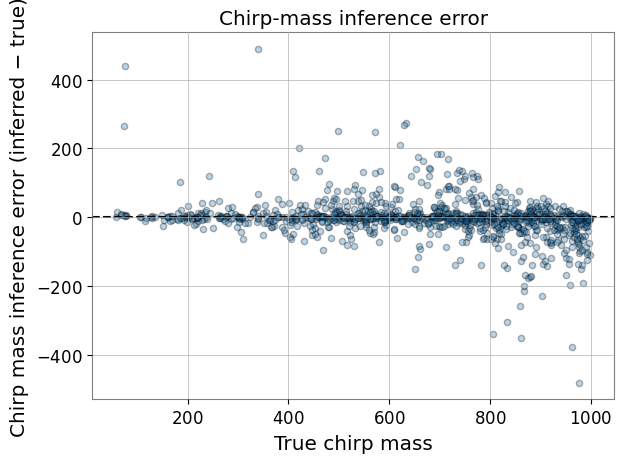

Mean error (bias):      -3.711
Mean absolute error:    33.946
RMS error:              62.662
Std of error:           62.552
90th percentile |error|: 86.655
99th percentile |error|: 259.252


In [17]:
true_cm = []
true_mr = []
mass_ratio_error = []
mass_ratio_std = []
chirp_mass_error = []
chirp_mass_std = []


result_files = sorted(os.listdir(f"/scratch/tpausch/test_data/{name}/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/{name}/results/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    result = payload["result"]

    posterior_samples = result.samples

    #q_samples = np.array(posterior_samples["mass_ratio"])

    # inference statistics
    #q_mean = np.mean(q_samples)
    #q_std = np.std(q_samples)
#
    #true_q = theta_true["mass_ratio"]

    cm_samples = np.array(posterior_samples["chirp_mass"])

    cm_mean = np.mean(cm_samples)
    cm_std = np.std(cm_samples)

    true_mr.append(theta_true["mass_ratio"])
    true_cm.append(theta_true["chirp_mass"])
    #mass_ratio_error.append(q_mean - true_q)
    #mass_ratio_std.append(q_std)
    chirp_mass_error.append(cm_mean - theta_true["chirp_mass"])
    chirp_mass_std.append(cm_std)


true_mr = np.array(true_mr)
true_cm = np.array(true_cm)

# ------------------------------------------------------------
# Error bars
# ------------------------------------------------------------

#plt.errorbar(
#    true_cm,
#    chirp_mass_error,
#    yerr=chirp_mass_std,
#    fmt="none",
#    capsize=4,
#    alpha=0.5,
#    color="gray",
#)

# ------------------------------------------------------------
# Colored scatter points
# ------------------------------------------------------------

sc = plt.scatter(
    true_cm,
    chirp_mass_error,
    s=20,
    edgecolor="black",
    alpha=0.3
)

# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axhline(0, linestyle="--", color="black")


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("True chirp mass")
plt.ylabel("Chirp mass inference error (inferred − true)")

plt.title("Chirp-mass inference error")

plt.grid(True)

plt.tight_layout()
plt.show()

cm_err = np.asarray(chirp_mass_error)

mean_error = np.mean(cm_err)          # signed average bias (over/under-estimation)
mean_abs_error = np.mean(np.abs(cm_err))  # average magnitude of deviation
rms_error = np.sqrt(np.mean(cm_err**2))   # RMS deviation, penalizes outliers more
std_error = np.std(cm_err)            # spread of the errors around their mean
p90_abs_error = np.percentile(np.abs(cm_err), 90)
p99_abs_error = np.percentile(np.abs(cm_err), 99)


print(f"Mean error (bias):      {mean_error:.3f}")
print(f"Mean absolute error:    {mean_abs_error:.3f}")
print(f"RMS error:              {rms_error:.3f}")
print(f"Std of error:           {std_error:.3f}")
print(f"90th percentile |error|: {p90_abs_error:.3f}")
print(f"99th percentile |error|: {p99_abs_error:.3f}")

### Unload Stage 1 Model

In [ ]:


# Delete the model object (and any other references you may have kept,
# e.g. main_pm.network, main_pm.optimizer, etc.)
del main_pm

# Force Python garbage collection
gc.collect()

# Release cached (but unused) memory back to the GPU allocator
torch.cuda.empty_cache()

## Distribute Injections to Stage 2 Models